<h3>This notebook is for feature engineering and prepration before parsing data to the machine learning models</h3>

<li>Adding imports</li>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

<li>Reading the data and displaying the first 5 snapshots</li>

In [22]:
file_path = "../../Data/Preprocessed/"
data = pd.read_parquet(file_path + "cleaned_training_data_V1.parquet")
data.head()

,Store,Date,DayOfWeek,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionDistanceMissing,CompetitionOpenMissing,StateHoliday,SchoolHoliday,Promo,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,StoreType,Assortment,Sales
0,1,2015-07-31,5,1270.0,9.0,2008.0,False,False,0,1,True,False,0.0,0.0,no_promo,c,a,8.568456
1,2,2015-07-31,5,570.0,11.0,2007.0,False,False,0,1,True,True,2010.0,13.0,"Jan,Apr,Jul,Oct",a,a,8.710125
2,3,2015-07-31,5,14130.0,12.0,2006.0,False,False,0,1,True,True,2011.0,14.0,"Jan,Apr,Jul,Oct",a,a,9.025696
3,4,2015-07-31,5,620.0,9.0,2009.0,False,False,0,1,True,False,0.0,0.0,no_promo,c,c,9.546455
4,5,2015-07-31,5,29910.0,4.0,2015.0,False,False,0,1,True,False,0.0,0.0,no_promo,a,a,8.480944


In [23]:
data.columns

Index(['Store', 'Date', 'DayOfWeek', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
       'CompetitionDistanceMissing', 'CompetitionOpenMissing', 'StateHoliday',
       'SchoolHoliday', 'Promo', 'Promo2', 'Promo2SinceYear',
       'Promo2SinceWeek', 'PromoInterval', 'StoreType', 'Assortment', 'Sales'],
      dtype='object')

<li>Time feature engineering - Extracting day, month, year from the data</li>
<p>We also will lable the month start and end days as well as the weekends</p>

In [24]:
data["Date"] = pd.to_datetime(data["Date"])

data["Year"]        = data["Date"].dt.year.astype("int16")
data["Month"]       = data["Date"].dt.month.astype("int8")
data["Week"]        = data["Date"].dt.isocalendar().week.astype("int8")
data["IsWeekend"]   = (data["DayOfWeek"] >= 6).astype("bool")
data["IsMonthStart"] = data["Date"].dt.is_month_start.astype("bool")
data["IsMonthEnd"]   = data["Date"].dt.is_month_end.astype("bool")

<p>Let's calculate how long has a competitor opened (in months) or a competitor promo has been active (in weeks)</p>

In [25]:
data["CompetitionOpenMonths"] = np.where(
    data["CompetitionOpenMissing"],
    -1,
    (data["Year"] - data["CompetitionOpenSinceYear"]) * 12
    + (data["Month"] - data["CompetitionOpenSinceMonth"])
)
data["CompetitionOpenMonths"] = data["CompetitionOpenMonths"].clip(lower=0, upper=600).astype("float32")

In [26]:
data["Promo2ActiveWeeks"] = np.where(
    data["Promo2"] == False,
    0,
    (data["Year"] - data["Promo2SinceYear"]) * 52
    + (data["Week"] - data["Promo2SinceWeek"])
)
data["Promo2ActiveWeeks"] = data["Promo2ActiveWeeks"].clip(lower=0).astype("float32")

<p>Then, let's check if a competitor promo is active this month</p>

In [27]:
month_map = {
    "Jan": 1,  "Feb": 2,  "Mar": 3,  "Apr": 4,
    "May": 5,  "Jun": 6,  "Jul": 7,  "Aug": 8,
    "Sept": 9, "Sep": 9, "Oct": 10, "Nov": 11, 
    "Dec": 12
}

def is_promo2_active(row):
    if row["PromoInterval"] == "no_promo":
        return False
    months = [month_map[m] for m in row["PromoInterval"].split(",")]
    return row["Month"] in months

data["IsPromo2Active"] = data.apply(is_promo2_active, axis=1).astype("bool")

<p>Therefore, we will drop the redundant columns to reduce dimensionality and multi co-linearity</p>

In [28]:
data.drop(columns=[
    "Date",
    "CompetitionOpenSinceYear",
    "CompetitionOpenSinceMonth",
    "Promo2SinceYear",
    "Promo2SinceWeek",
    "PromoInterval",
    "Month"
]
,axis=1, inplace=True)
data.head(10)

,Store,DayOfWeek,CompetitionDistance,CompetitionDistanceMissing,CompetitionOpenMissing,StateHoliday,SchoolHoliday,Promo,Promo2,StoreType,Assortment,Sales,Year,Week,IsWeekend,IsMonthStart,IsMonthEnd,CompetitionOpenMonths,Promo2ActiveWeeks,IsPromo2Active
0,1,5,1270.0,False,False,0,1,True,False,c,a,8.568456,2015,31,False,False,True,82.0,0.0,False
1,2,5,570.0,False,False,0,1,True,True,a,a,8.710125,2015,31,False,False,True,92.0,278.0,True
2,3,5,14130.0,False,False,0,1,True,True,a,a,9.025696,2015,31,False,False,True,103.0,225.0,True
3,4,5,620.0,False,False,0,1,True,False,c,c,9.546455,2015,31,False,False,True,70.0,0.0,False
4,5,5,29910.0,False,False,0,1,True,False,a,a,8.480944,2015,31,False,False,True,3.0,0.0,False
5,6,5,310.0,False,False,0,1,True,False,a,a,8.639588,2015,31,False,False,True,19.0,0.0,False
6,7,5,24000.0,False,False,0,1,True,False,a,c,9.638480,2015,31,False,False,True,27.0,0.0,False
7,8,5,7520.0,False,False,0,1,True,False,a,a,9.046880,2015,31,False,False,True,9.0,0.0,False
8,9,5,2030.0,False,False,0,1,True,False,a,c,9.055439,2015,31,False,False,True,179.0,0.0,False
9,10,5,3160.0,False,False,0,1,True,False,a,a,8.879751,2015,31,False,False,True,70.0,0.0,False


<p>After extracting useful info from some columns and deleting redundant columns, we need to encode categorical columns and check if there is a need to reduce the dimensions</p>

<li>First, we split the features according to types</li>

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   Store                       844338 non-null  int16   
 1   DayOfWeek                   844338 non-null  int8    
 2   CompetitionDistance         844338 non-null  float32 
 3   CompetitionDistanceMissing  844338 non-null  bool    
 4   CompetitionOpenMissing      844338 non-null  bool    
 5   StateHoliday                844338 non-null  category
 6   SchoolHoliday               844338 non-null  int8    
 7   Promo                       844338 non-null  bool    
 8   Promo2                      844338 non-null  bool    
 9   StoreType                   844338 non-null  category
 10  Assortment                  844338 non-null  category
 11  Sales                       844338 non-null  float64 
 12  Year                        844338 non-null  int16   
 13 

In [30]:
numeric_columns = data.select_dtypes(include=np.number).columns
numeric_columns

Index(['Store', 'DayOfWeek', 'CompetitionDistance', 'SchoolHoliday', 'Sales',
       'Year', 'Week', 'CompetitionOpenMonths', 'Promo2ActiveWeeks'],
      dtype='object')

In [31]:
categorical_columns = data.select_dtypes(exclude=np.number).columns
categorical_columns

Index(['CompetitionDistanceMissing', 'CompetitionOpenMissing', 'StateHoliday',
       'Promo', 'Promo2', 'StoreType', 'Assortment', 'IsWeekend',
       'IsMonthStart', 'IsMonthEnd', 'IsPromo2Active'],
      dtype='object')

<li>Use dummy encoder for columns of type category and converting all categorical columns into numeric ones</li>

In [32]:
category_columns = data.select_dtypes(include="category").columns.to_list()
lable_encoder = LabelEncoder()
for col in category_columns:
    data[col] = data[col].astype(str)
    data[col] = lable_encoder.fit_transform(data[col]).astype(np.int8)

In [33]:
bool_columns = data.select_dtypes(include="bool").columns.to_list()
data[bool_columns] = data[bool_columns].astype(np.int8)

In [34]:
data.head(10)

,Store,DayOfWeek,CompetitionDistance,CompetitionDistanceMissing,CompetitionOpenMissing,StateHoliday,SchoolHoliday,Promo,Promo2,StoreType,Assortment,Sales,Year,Week,IsWeekend,IsMonthStart,IsMonthEnd,CompetitionOpenMonths,Promo2ActiveWeeks,IsPromo2Active
0,1,5,1270.0,0,0,0,1,1,0,2,0,8.568456,2015,31,0,0,1,82.0,0.0,0
1,2,5,570.0,0,0,0,1,1,1,0,0,8.710125,2015,31,0,0,1,92.0,278.0,1
2,3,5,14130.0,0,0,0,1,1,1,0,0,9.025696,2015,31,0,0,1,103.0,225.0,1
3,4,5,620.0,0,0,0,1,1,0,2,2,9.546455,2015,31,0,0,1,70.0,0.0,0
4,5,5,29910.0,0,0,0,1,1,0,0,0,8.480944,2015,31,0,0,1,3.0,0.0,0
5,6,5,310.0,0,0,0,1,1,0,0,0,8.639588,2015,31,0,0,1,19.0,0.0,0
6,7,5,24000.0,0,0,0,1,1,0,0,2,9.638480,2015,31,0,0,1,27.0,0.0,0
7,8,5,7520.0,0,0,0,1,1,0,0,0,9.046880,2015,31,0,0,1,9.0,0.0,0
8,9,5,2030.0,0,0,0,1,1,0,0,2,9.055439,2015,31,0,0,1,179.0,0.0,0
9,10,5,3160.0,0,0,0,1,1,0,0,0,8.879751,2015,31,0,0,1,70.0,0.0,0


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Store                       844338 non-null  int16  
 1   DayOfWeek                   844338 non-null  int8   
 2   CompetitionDistance         844338 non-null  float32
 3   CompetitionDistanceMissing  844338 non-null  int8   
 4   CompetitionOpenMissing      844338 non-null  int8   
 5   StateHoliday                844338 non-null  int8   
 6   SchoolHoliday               844338 non-null  int8   
 7   Promo                       844338 non-null  int8   
 8   Promo2                      844338 non-null  int8   
 9   StoreType                   844338 non-null  int8   
 10  Assortment                  844338 non-null  int8   
 11  Sales                       844338 non-null  float64
 12  Year                        844338 non-null  int16  
 13  Week          

<li>Check the correlation of each feature with the target</li>

In [36]:
corr = data.corr()["Sales"].drop("Sales").sort_values()
print("Low correlation features (< 0.01):")
print(corr[corr.abs() < 0.01])

Low correlation features (< 0.01):
Store                     0.001162
CompetitionOpenMissing    0.003814
StateHoliday              0.008378
Name: Sales, dtype: float64


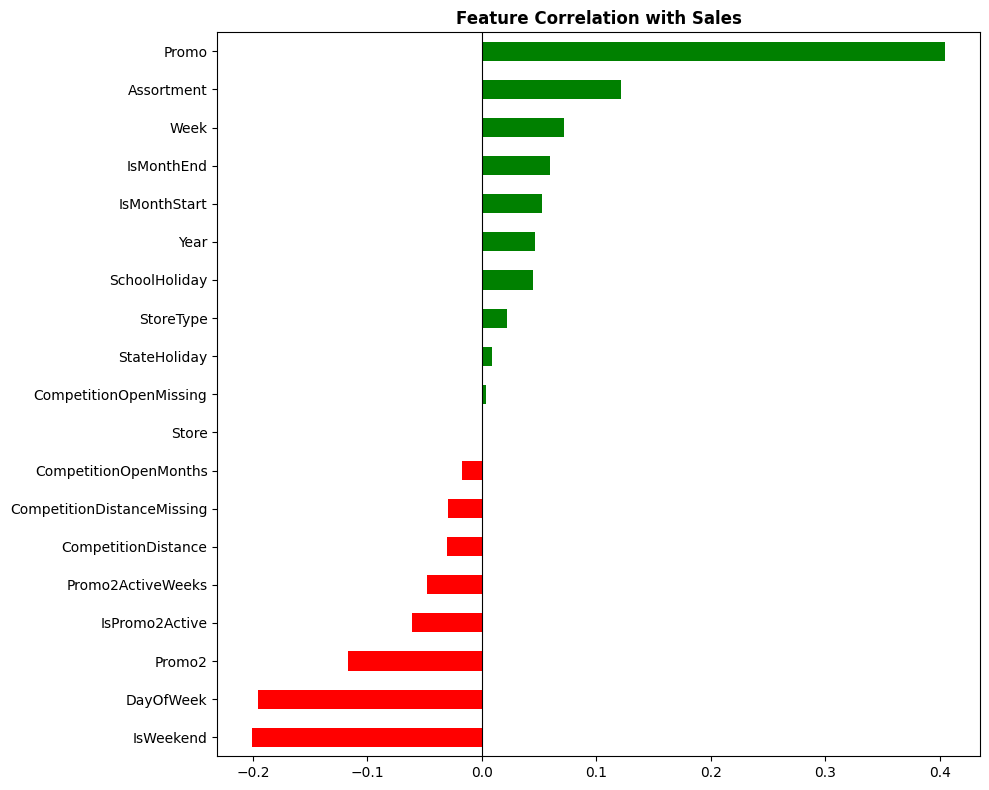

In [37]:
plt.figure(figsize=(10, 8))
corr.plot(kind="barh", color=corr.map(lambda x: "green" if x > 0 else "red"))
plt.title("Feature Correlation with Sales", fontweight="bold")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [38]:
# Target Encoding for Store
store_mean = data.groupby('Store')['Sales'].mean()
data['Store_TargetEnc'] = data['Store'].map(store_mean).astype('float32')
data.drop(columns=['Store'], inplace=True)

In [39]:
check = data[["DayOfWeek","IsWeekend"]]
check.value_counts()

DayOfWeek  IsWeekend
6          1            144052
2          0            143955
3          0            141922
5          0            138633
1          0            137557
4          0            134626
7          1              3593
Name: count, dtype: int64

In [40]:
data.to_parquet(file_path + "featured_training_data_V2.parquet", index=False)
print("Saved! Shape:", data.shape)
print("Columns:", data.columns.tolist())

Saved! Shape: (844338, 20)
Columns: ['DayOfWeek', 'CompetitionDistance', 'CompetitionDistanceMissing', 'CompetitionOpenMissing', 'StateHoliday', 'SchoolHoliday', 'Promo', 'Promo2', 'StoreType', 'Assortment', 'Sales', 'Year', 'Week', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'CompetitionOpenMonths', 'Promo2ActiveWeeks', 'IsPromo2Active', 'Store_TargetEnc']
